# Retrieve chembl data

The purpose of this notebook is to retrieve all compounds on Chembl with PPB (fraction unbound) 

In [1]:
from pathlib import Path
import pathlib
import csv

import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.notebook import tqdm

Protein and data variables.

In [2]:
readout = 'ppb_f_ub'

In [3]:
# define paths
HERE = Path(pathlib.Path.cwd())
DATA = HERE / f"data_{readout}"
DATA.mkdir(parents=True, exist_ok=True)

### Download ligands and bioactivity data from Chembl.

In [4]:
from chembl_webresource_client.new_client import new_client
from tqdm.notebook import tqdm
import concurrent.futures

/home/corey/miniconda3/envs/docking_md/lib/python3.11/site-packages/chembl_webresource_client/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __version__ = __import__('pkg_resources').get_distribution('chembl_webresource_client').version


In [5]:
from chembl_webresource_client.new_client import new_client
import concurrent.futures
import time
import threading

BASE_KEYWORDS = [
    "plasma protein binding",
    "protein binding",
    "fraction unbound",
    "unbound fraction",
    "percent unbound",
    "fraction unbound in plasma",
    "ppb",
    "free fraction",
    "plasma binding",
    "bound fraction",
    "fu",
    "fraction bound",
    "plasma free fraction",
    "serum protein binding",
    "plasma unbound",
    "binding to plasma proteins"
]

SPECIES = ["human", "rat", "mouse", "dog", "monkey"]

# Create combinations like "human plasma protein binding"
ppb_keywords = sorted(set(BASE_KEYWORDS + [f"{sp} {kw}" for sp in SPECIES for kw in BASE_KEYWORDS]))

MAX_WORKERS = 6
TIMEOUT = 90          # seconds per keyword
MAX_RETRIES = 2
RETRY_DELAY = 5       # seconds between retries

status_lock = threading.Lock()
keyword_status = {kw: "pending" for kw in ppb_keywords}

# helpers
def query_keyword(kw):
    """Query ChEMBL for assays whose description includes the keyword (case-insensitive)."""
    with status_lock:
        keyword_status[kw] = "running"

    for attempt in range(1, MAX_RETRIES + 1):
        start_time = time.time()
        try:
            assays = []
            for a in new_client.assay.filter(description__icontains=kw):
                assays.append(a["assay_chembl_id"])
                if time.time() - start_time > TIMEOUT:
                    raise TimeoutError(f"'{kw}' exceeded {TIMEOUT}s, aborting early.")

            elapsed = time.time() - start_time
            with status_lock:
                keyword_status[kw] = f"done ({len(assays)} assays, {elapsed:.1f}s)"
            print(f"✓ '{kw}' done in {elapsed:.1f}s ({len(assays)} assays)")
            return assays

        except TimeoutError as e:
            with status_lock:
                keyword_status[kw] = f"timeout after {TIMEOUT}s"
            print(f"{e}")
            return []

        except Exception as e:
            print(f"Attempt {attempt} for '{kw}' failed: {e}")
            if attempt < MAX_RETRIES:
                time.sleep(RETRY_DELAY)
            else:
                with status_lock:
                    keyword_status[kw] = f"failed ({e})"
                return []

def print_status():
    """Display currently running keywords."""
    with status_lock:
        running = {k: v for k, v in keyword_status.items() if v == "running"}
    if running:
        print("\n⏳ Still running:")
        for k in running:
            print(f"  - {k}")
    else:
        print("\nNo keywords currently running.")

print(f"Starting assay queries for {len(ppb_keywords)} keywords...")

all_results = []
start = time.time()

with concurrent.futures.ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {executor.submit(query_keyword, kw): kw for kw in ppb_keywords}
    for future in tqdm(concurrent.futures.as_completed(futures), total=len(futures), desc="Fetching assay sets"):
        kw = futures[future]
        try:
            result = future.result()
            all_results.append(result)
        except Exception as e:
            with status_lock:
                keyword_status[kw] = f"failed ({e})"
            print(f"'{kw}' failed: {e}")
        print_status()

assay_ids = {aid for sublist in all_results for aid in sublist}
elapsed = time.time() - start

print("\nFinal keyword statuses:")
for k, v in keyword_status.items():
    print(f"  - {k}: {v}")

print(f"\n Found {len(assay_ids)} unique PPB-related assays in {elapsed:.1f}s.")


Starting assay queries for 96 keywords...
✓ 'dog bound fraction' done in 0.0s (0 assays)
✓ 'dog fraction unbound' done in 0.0s (0 assays)
✓ 'binding to plasma proteins' done in 0.0s (0 assays)
✓ 'dog fraction bound' done in 0.0s (0 assays)


Fetching assay sets:   0%|          | 0/96 [00:00<?, ?it/s]

✓ 'dog binding to plasma proteins' done in 0.1s (0 assays)

⏳ Still running:
  - bound fraction
  - dog fraction unbound in plasma
  - dog free fraction
  - dog fu
  - dog percent unbound
  - dog plasma binding

⏳ Still running:
  - bound fraction
  - dog fraction unbound in plasma
  - dog free fraction
  - dog fu
  - dog percent unbound
  - dog plasma binding

⏳ Still running:
  - bound fraction
  - dog fraction unbound in plasma
  - dog free fraction
  - dog fu
  - dog percent unbound
  - dog plasma binding

⏳ Still running:
  - bound fraction
  - dog fraction unbound in plasma
  - dog free fraction
  - dog fu
  - dog percent unbound
  - dog plasma binding

⏳ Still running:
  - bound fraction
  - dog fraction unbound in plasma
  - dog free fraction
  - dog fu
  - dog percent unbound
  - dog plasma binding
✓ 'dog fu' done in 0.0s (1 assays)

⏳ Still running:
  - bound fraction
  - dog fraction unbound in plasma
  - dog free fraction
  - dog percent unbound
  - dog plasma binding
  - d

In [6]:
len(assay_ids)

4382

In [7]:
# Async batch fetching of ppb data using aiohttp
import aiohttp
import asyncio
import nest_asyncio
from tqdm.notebook import tqdm
import math

nest_asyncio.apply()  # Needed to run asyncio in Jupyter

# Parameters
BATCH_SIZE = 50
MAX_CONCURRENT_REQUESTS = 10
RELEVANT_PATTERNS = ["unbound", "binding", "fraction", "fu", "ppb", "free"]


# Build assay ID batches
assay_ids = list(assay_ids)
assay_batches = [assay_ids[i:i+BATCH_SIZE] for i in range(0, len(assay_ids), BATCH_SIZE)]

# Helper to format assay_chembl_id__in for URL
def build_url(batch):
    base = "https://www.ebi.ac.uk/chembl/api/data/activity.json"
    assay_filter = "&".join([f"assay_chembl_id__in={aid}" for aid in batch])
    fields = "activity_id,assay_chembl_id,molecule_chembl_id,standard_type,standard_units,relation,standard_value,target_chembl_id"
    url = f"{base}?{assay_filter}&only={fields}&limit=1000"
    return url

# Async request function with retry and exponential backoff
async def fetch_batch(session, batch, max_retries=3, base_delay=1.0):
    url = build_url(batch)
    attempt = 0
    while attempt <= max_retries:
        try:
            async with session.get(url) as response:
                if response.status == 200:
                    data = await response.json()
                    activities = data.get("activities", [])
                    # Filter by standard_type
                    filtered = [
                        act for act in activities
                        if any(p in act.get("standard_type", "").lower() for p in RELEVANT_PATTERNS)
                    ]
                    return filtered
                elif response.status in {429, 500, 502, 503, 504}:
                    # Retry-able status codes
                    delay = base_delay * (2 ** attempt)
                    print(f"[Retry {attempt+1}] HTTP {response.status} for batch {batch[:2]}... sleeping {delay:.1f}s")
                    await asyncio.sleep(delay)
                    attempt += 1
                else:
                    print(f"[Fail] HTTP {response.status} for batch {batch[:2]}")
                    return []
        except Exception as e:
            delay = base_delay * (2 ** attempt)
            print(f"[Exception {attempt+1}] {e} for batch {batch[:2]}... sleeping {delay:.1f}s")
            await asyncio.sleep(delay)
            attempt += 1

    print(f"[Max retries exceeded] Failed to fetch batch {batch[:2]}")
    return []


# Main async runner
async def fetch_all_batches(batches):
    connector = aiohttp.TCPConnector(limit_per_host=MAX_CONCURRENT_REQUESTS)
    async with aiohttp.ClientSession(connector=connector) as session:
        tasks = [fetch_batch(session, batch) for batch in batches]
        results = []
        for f in tqdm(asyncio.as_completed(tasks), total=len(tasks), desc="Async batch fetching"):
            result = await f
            results.extend(result)
        return results

# Run it
print("Starting async fetch of activity data...")
all_activities = await fetch_all_batches(assay_batches)
print(f"Fetched {len(all_activities)} relevant PPB records.")


Starting async fetch of activity data...


Async batch fetching:   0%|          | 0/88 [00:00<?, ?it/s]

Fetched 13062 relevant PPB records.


In [8]:
import time
from tqdm.notebook import tqdm

# Retry helper with exponential backoff
def retry_request(func, *args, retries=3, delay=1.0):
    for attempt in range(retries):
        try:
            return func(*args)
        except Exception as e:
            if attempt == retries - 1:
                raise e
            time.sleep(delay * (2 ** attempt))

# Batch fetch function with retry
def batch_fetch(client, resource, ids, batch_size=20):
    data = {}
    for i in tqdm(range(0, len(ids), batch_size), desc=f"Fetching {resource}s"):
        batch = ids[i:i+batch_size]
        success = False
        for attempt in range(3):
            try:
                results = getattr(client, resource).filter(**{f"{resource}_chembl_id__in": batch})
                for r in results:
                    data[r[f"{resource}_chembl_id"]] = r
                success = True
                break
            except Exception as e:
                wait = 2 ** attempt
                print(f"[Retry {attempt+1}] fetching {resource}s batch failed: {e}, retrying in {wait}s")
                time.sleep(wait)
        if not success:
            print(f"[Fail] Could not fetch batch {batch} of {resource}s after retries.")
    return data

print("Starting bulk fetch of assay, molecule, and target data...")

# Extract unique IDs from activities
assay_ids = list(set(act.get("assay_chembl_id") for act in all_activities if act.get("assay_chembl_id")))
molecule_ids = list(set(act.get("molecule_chembl_id") for act in all_activities if act.get("molecule_chembl_id")))
target_ids = list(set(act.get("target_chembl_id") for act in all_activities if act.get("target_chembl_id")))

# Bulk fetch each resource once
assay_data = batch_fetch(new_client, "assay", assay_ids)
molecule_data = batch_fetch(new_client, "molecule", molecule_ids)
target_data = batch_fetch(new_client, "target", target_ids)

print("Processing activities locally...")

processed = []
for act in tqdm(all_activities, desc="Processing activities"):
    try:
        assay = assay_data.get(act.get("assay_chembl_id")) or {}
        molecule = molecule_data.get(act.get("molecule_chembl_id")) or {}
        target = target_data.get(act.get("target_chembl_id")) or {}

        # Safe SMILES extraction
        mol_struct = molecule.get("molecule_structures")
        smiles = mol_struct.get("canonical_smiles") if isinstance(mol_struct, dict) else None

        # Safe target organism
        organism = None
        if isinstance(target, dict):
            organism = target.get("organism")
        elif isinstance(target, list) and len(target) > 0:
            organism = target[0].get("organism")

        # Build clean record
        record = {
            "activity_id": act.get("activity_id"),
            "assay_chembl_id": act.get("assay_chembl_id"),
            "assay_description": assay.get("description"),
            "assay_type": assay.get("assay_type"),
            "molecule_chembl_id": act.get("molecule_chembl_id"),
            "smiles": smiles,
            "target_chembl_id": act.get("target_chembl_id"),
            "target_organism": organism,
            "standard_type": act.get("standard_type"),
            "standard_units": act.get("standard_units"),
            "relation": act.get("relation"),
            "standard_value": act.get("standard_value"),
            "error": None
        }

    except Exception as e:
        # Catch anything unexpected so it doesn't break the loop
        record = {
            "activity_id": act.get("activity_id"),
            "assay_chembl_id": act.get("assay_chembl_id"),
            "molecule_chembl_id": act.get("molecule_chembl_id"),
            "target_chembl_id": act.get("target_chembl_id"),
            "error": f"Processing error: {type(e).__name__}: {e}"
        }

    processed.append(record)

print(f"Done! Processed {len(processed)} PPB records.")


Starting bulk fetch of assay, molecule, and target data...


Fetching assays:   0%|          | 0/187 [00:00<?, ?it/s]

Fetching molecules:   0%|          | 0/337 [00:00<?, ?it/s]

Fetching targets:   0%|          | 0/3 [00:00<?, ?it/s]

Processing activities locally...


Processing activities:   0%|          | 0/13062 [00:00<?, ?it/s]

Done! Processed 13062 PPB records.


In [9]:
len(processed)

13062

In [10]:
# Because we queried more than one LogD readout, we need to de-duplicate.

unique_activities = list({a["activity_id"]: a for a in processed}.values())

In [11]:
# def normalize_fu(value, relation, standard_type):
#     if value is None:
#         return None
#     try:
#         v = float(value)
#     except ValueError:
#         return None
#     t = standard_type.lower()
#     if "percent bound" in t or "protein binding" in t:
#         fu = 1 - (v / 100)
#     elif "%" in t and "unbound" in t:
#         fu = v / 100
#     else:
#         fu = v
#     return max(0.0, min(1.0, fu))


# Check distribution of PPB data.

In [27]:
df = pd.DataFrame(unique_activities)

In [28]:
len(df)

13062

Infer species from `assay_description`.

In [29]:
import re

# Define common species patterns
species_map = {
    r"\bhuman\b|\bhomo sapiens\b": "Homo sapiens",
    r"\brat\b|\brattus\b": "Rattus norvegicus",
    r"\bmouse\b|\bmurine\b|\bmus musculus\b": "Mus musculus",
    r"\bdog\b|\bcanine\b|\bcanis familiaris\b": "Canis familiaris",
    r"\bmonkey\b|\bcynomolgus\b|\bmacaca\b": "Macaca sp.",
    r"\brabbit\b": "Oryctolagus cuniculus",
    r"\bpig\b|\bsus scrofa\b": "Sus scrofa"
}

# Only fill in missing target_organism
mask_missing = df["target_organism"].isna() | (df["target_organism"] == "")

for pattern, species in species_map.items():
    matches = df["assay_description"].str.contains(pattern, flags=re.IGNORECASE, na=False)
    df.loc[mask_missing & matches, "target_organism"] = species

print(f"Filled target_organism for {df['target_organism'].notna().sum()} / {len(df)} records.")


Filled target_organism for 12308 / 13062 records.


Aaaaaand infer units from `standard_type` column.

In [31]:
# Fill missing units based on 'standard_type'
mask_missing_units = df["standard_units"].isna() | (df["standard_units"] == "")
mask_fu_type = df["standard_type"].str.lower().str.strip().isin(["fu", "fraction unbound", "unbound fraction", "Unbound", "Free"])

# Identify Fu-type records with missing units
mask_fu_missing = mask_missing_units & mask_fu_type

# Convert standard_value to numeric (safe conversion)
df["standard_value"] = pd.to_numeric(df["standard_value"], errors="coerce")

# Detect fractional values that are likely proportions (0 < value <= 1)
mask_fractional = mask_fu_missing & df["standard_value"].between(0, 1, inclusive="both")

# Scale fractional Fu values to percentages
df.loc[mask_fractional, "standard_value"] = df.loc[mask_fractional, "standard_value"] * 100

# Assign '%' as the standard_units for these Fu-type entries
df.loc[mask_fu_missing, "standard_units"] = "%"

print(f"✅ Filled {mask_fu_missing.sum()} missing 'standard_units' as '%' for Fu-type assays.")
print(f"✅ Converted {mask_fractional.sum()} Fu values from fractions to percentages.")


✅ Filled 12097 missing 'standard_units' as '%' for Fu-type assays.
✅ Converted 11596 Fu values from fractions to percentages.


/tmp/ipykernel_12891/1747405060.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate x labels
/tmp/ipykernel_12891/1747405060.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate x labels


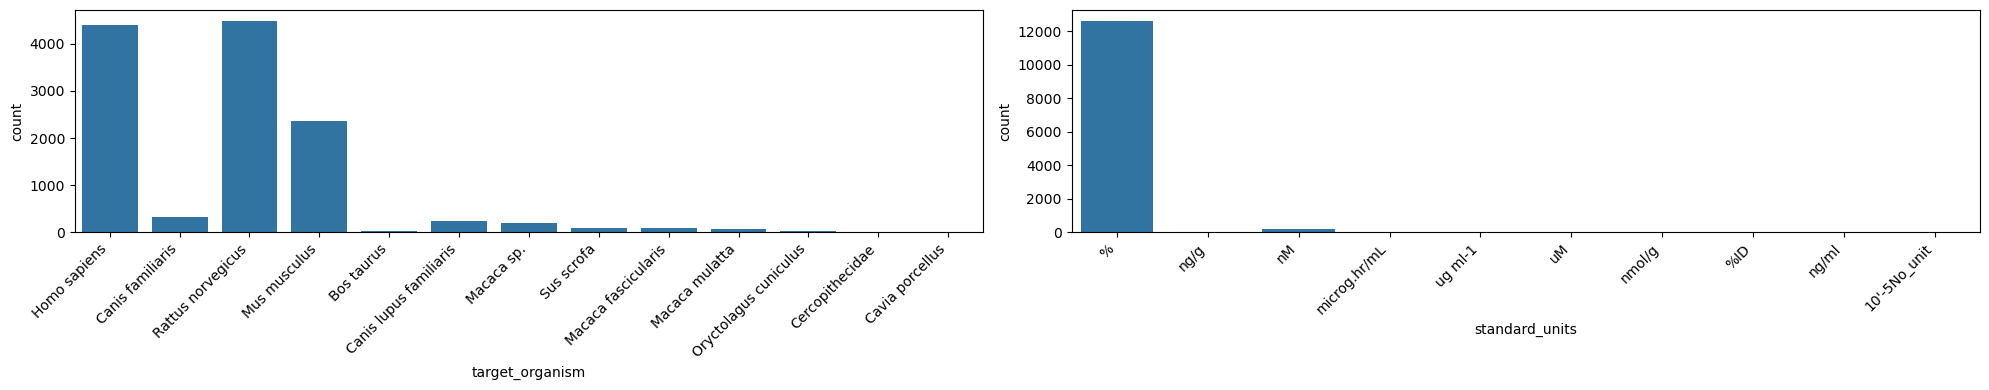

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ["target_organism", "standard_units"]
f, axs = plt.subplots(1, len(cols), figsize=(20, 4))

for ax, col in zip(axs, cols):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate x labels

f.tight_layout()

Keep only human records and those with % units and non-zero.

In [33]:
counts = df['standard_units'].value_counts()

print(counts)

standard_units
%               12638
nM                222
uM                 38
ng/g               11
nmol/g              5
ng/ml               4
ug ml-1             2
10'-5No_unit        2
microg.hr/mL        1
%ID                 1
Name: count, dtype: int64


In [34]:
df_filtered = df[(df['target_organism'] == 'Homo sapiens') & (df['standard_units'] == '%')]
len(df_filtered)

4377

Data is clearly unbalanced will need to sample.

/tmp/ipykernel_12891/3813164949.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['standard_value'] = df_filtered['standard_value'].astype(float)


<Axes: xlabel='standard_value', ylabel='Count'>

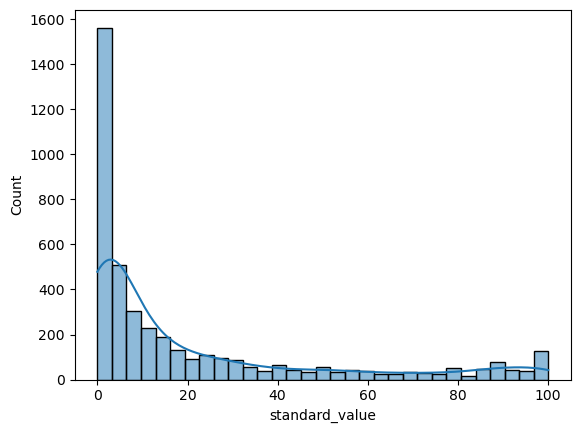

In [35]:
df_filtered['standard_value'] = df_filtered['standard_value'].astype(float)
sns.histplot(data=df_filtered, x="standard_value", kde=True)

How diverse is the data?

Parsed 4366 valid molecules out of 4377 records (99.7%).


[13:58:00] DEPRECATION WARNING: please use MorganGenerator
[13:58:00] DEPRECATION WARNING: please use MorganGenerator
[13:58:00] DEPRECATION WARNING: please use MorganGenerator
[13:58:00] DEPRECATION WARNING: please use MorganGenerator
[13:58:00] DEPRECATION WARNING: please use MorganGenerator
[13:58:00] DEPRECATION WARNING: please use MorganGenerator
[13:58:00] DEPRECATION WARNING: please use MorganGenerator
[13:58:00] DEPRECATION WARNING: please use MorganGenerator
[13:58:00] DEPRECATION WARNING: please use MorganGenerator
[13:58:00] DEPRECATION WARNING: please use MorganGenerator
[13:58:00] DEPRECATION WARNING: please use MorganGenerator
[13:58:00] DEPRECATION WARNING: please use MorganGenerator
[13:58:00] DEPRECATION WARNING: please use MorganGenerator
[13:58:00] DEPRECATION WARNING: please use MorganGenerator
[13:58:00] DEPRECATION WARNING: please use MorganGenerator
[13:58:00] DEPRECATION WARNING: please use MorganGenerator
[13:58:00] DEPRECATION WARNING: please use MorganGenerat

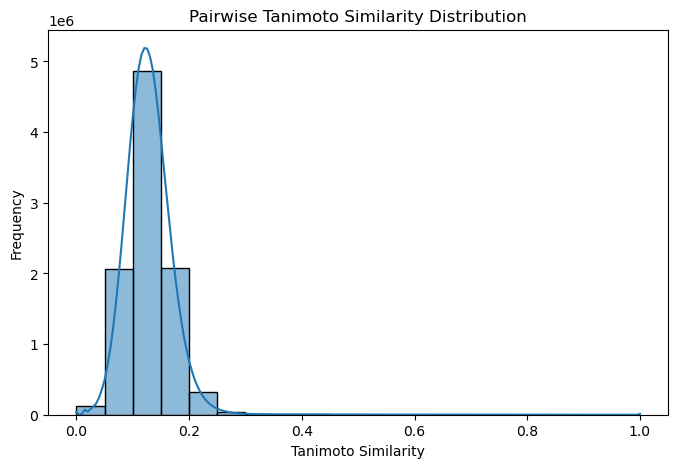

Number of molecule pairs: 9528795
Mean similarity: 0.129
Median similarity: 0.126
Max similarity: 1.000
Min similarity: 0.000


In [38]:
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Get rid of None SMILES
valid_smiles = [sm for sm in df_filtered.smiles.dropna() if isinstance(sm, str) and sm.strip()]
mols = []
for sm in valid_smiles:
    mol = Chem.MolFromSmiles(sm)
    if mol is not None:
        mols.append(mol)

print(f"Parsed {len(mols)} valid molecules out of {len(df_filtered)} records ({len(mols)/len(df_filtered)*100:.1f}%).")

if len(mols) < 2:
    raise ValueError("Not enough valid molecules to compute similarity.")

fps = [AllChem.GetMorganFingerprintAsBitVect(m, radius=2, nBits=1024) for m in mols]

# Pairwise similarities
similarities = []
num_mols = len(fps)
for i in range(num_mols):
    for j in range(i+1, num_mols):
        sim = DataStructs.TanimotoSimilarity(fps[i], fps[j])
        similarities.append(sim)

# --- Step 4: Plot ---
plt.figure(figsize=(8,5))
sns.histplot(similarities, bins=20, kde=True)
plt.title("Pairwise Tanimoto Similarity Distribution")
plt.xlabel("Tanimoto Similarity")
plt.ylabel("Frequency")
plt.savefig('_images/pairwise_tanimoto_similarity.png')
plt.show()

# --- Step 5: Summary statistics ---
print(f"Number of molecule pairs: {len(similarities)}")
print(f"Mean similarity: {np.mean(similarities):.3f}")
print(f"Median similarity: {np.median(similarities):.3f}")
print(f"Max similarity: {np.max(similarities):.3f}")
print(f"Min similarity: {np.min(similarities):.3f}")

Almost no molecular similarity - good. 

How about chemical space visualisation with tSNE?

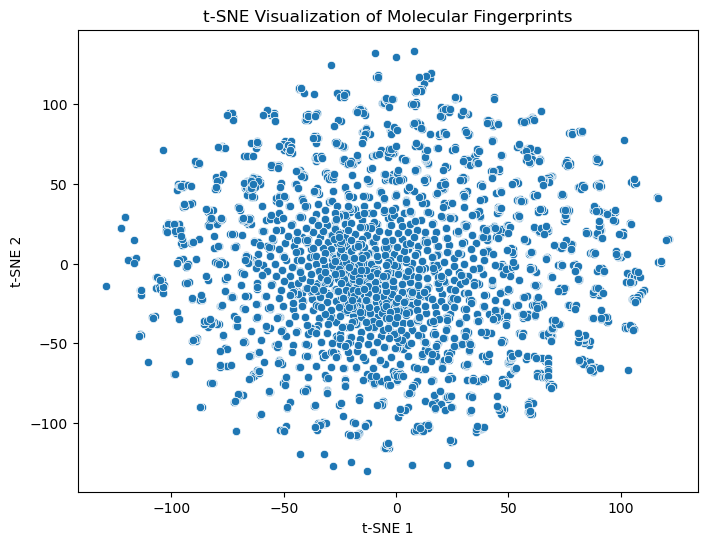

In [ ]:
from sklearn.manifold import TSNE
import pandas as pd

# Use the same fingerprints from above, convert to numpy arrays
def fp_to_array(fp):
    arr = np.zeros((1,), dtype=np.uint8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

fp_arrays = np.array([fp_to_array(fp) for fp in fps])

# Run t-SNE to reduce fingerprint dimensionality to 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
fp_tsne = tsne.fit_transform(fp_arrays)

# Plot t-SNE embedding
plt.figure(figsize=(8,6))
sns.scatterplot(x=fp_tsne[:,0], y=fp_tsne[:,1])
plt.title("t-SNE Visualization of Molecular Fingerprints")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.savefig('_images/cluster_molecule_tsne.png')
plt.show()



Number of molecules: 4366
Number of unique scaffolds: 2404
Scaffold diversity ratio: 0.551

Top 10 most frequent scaffolds:
c1ccccc1: 109
: 35
O=C(NCC(=O)N1CCC[C@H]1C(=O)NCc1ccc(-c2cncs2)cc1)C1CC1: 32
c1ccc([C@H]2NCCc3c2[nH]c2ccccc32)cc1: 28
O=C1c2cncnc2OCCN1c1ccc(-c2ccccc2)cc1: 26
O=C1NC(=O)C2(Cc3cc4c(-n5cncn5)noc4cc3N3CCOC[C@@H]32)C(=O)N1: 22
O=C(N[C@H]1CNC1=O)/C(=N\OCc1cc(=O)cc[nH]1)c1cscn1: 22
O=C1CCC(NC(=O)c2ccccc2)C(=O)N1: 19
O=C1CNCCN1c1cccc(-c2ccc3cncnn23)c1: 19
c1cc([C@H]2NCCc3c2ccc2[nH]ncc32)ncc1NC1CNC1: 18


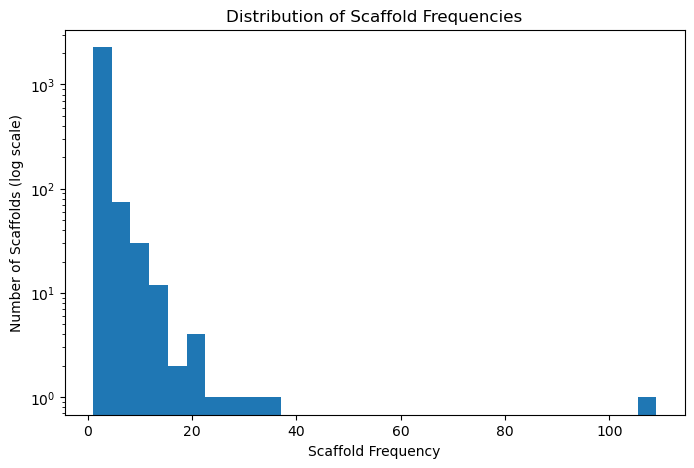

In [40]:
from rdkit.Chem.Scaffolds import MurckoScaffold
from collections import Counter

# Extract Bemis-Murcko scaffolds for each molecule
scaffolds = [MurckoScaffold.GetScaffoldForMol(m) for m in mols if m is not None]

# Convert scaffold molecules back to SMILES for easier counting
scaffold_smiles = [Chem.MolToSmiles(scaffold) for scaffold in scaffolds]

# Count frequency of each scaffold
scaffold_counts = Counter(scaffold_smiles)

# Calculate number of unique scaffolds and total molecules
num_unique_scaffolds = len(scaffold_counts)
num_molecules = len(mols)
scaffold_diversity_ratio = num_unique_scaffolds / num_molecules

print(f"Number of molecules: {num_molecules}")
print(f"Number of unique scaffolds: {num_unique_scaffolds}")
print(f"Scaffold diversity ratio: {scaffold_diversity_ratio:.3f}")

# Print top 10 most common scaffolds
print("\nTop 10 most frequent scaffolds:")
for scaffold, count in scaffold_counts.most_common(10):
    print(f"{scaffold}: {count}")

# Optional: Plot scaffold frequency distribution
import matplotlib.pyplot as plt

counts = list(scaffold_counts.values())
plt.figure(figsize=(8,5))
plt.hist(counts, bins=30, log=True)  # Log scale to show skew
plt.xlabel("Scaffold Frequency")
plt.ylabel("Number of Scaffolds (log scale)")
plt.title("Distribution of Scaffold Frequencies")
plt.savefig('_images/scaffold_freq.png')
plt.show()


[13:58:51] DEPRECATION WARNING: please use MorganGenerator
[13:58:51] DEPRECATION WARNING: please use MorganGenerator
[13:58:51] DEPRECATION WARNING: please use MorganGenerator
[13:58:51] DEPRECATION WARNING: please use MorganGenerator
[13:58:51] DEPRECATION WARNING: please use MorganGenerator
[13:58:51] DEPRECATION WARNING: please use MorganGenerator
[13:58:51] DEPRECATION WARNING: please use MorganGenerator
[13:58:51] DEPRECATION WARNING: please use MorganGenerator
[13:58:51] DEPRECATION WARNING: please use MorganGenerator
[13:58:51] DEPRECATION WARNING: please use MorganGenerator
[13:58:51] DEPRECATION WARNING: please use MorganGenerator
[13:58:51] DEPRECATION WARNING: please use MorganGenerator
[13:58:51] DEPRECATION WARNING: please use MorganGenerator
[13:58:51] DEPRECATION WARNING: please use MorganGenerator
[13:58:51] DEPRECATION WARNING: please use MorganGenerator
[13:58:51] DEPRECATION WARNING: please use MorganGenerator
[13:58:51] DEPRECATION WARNING: please use MorganGenerat

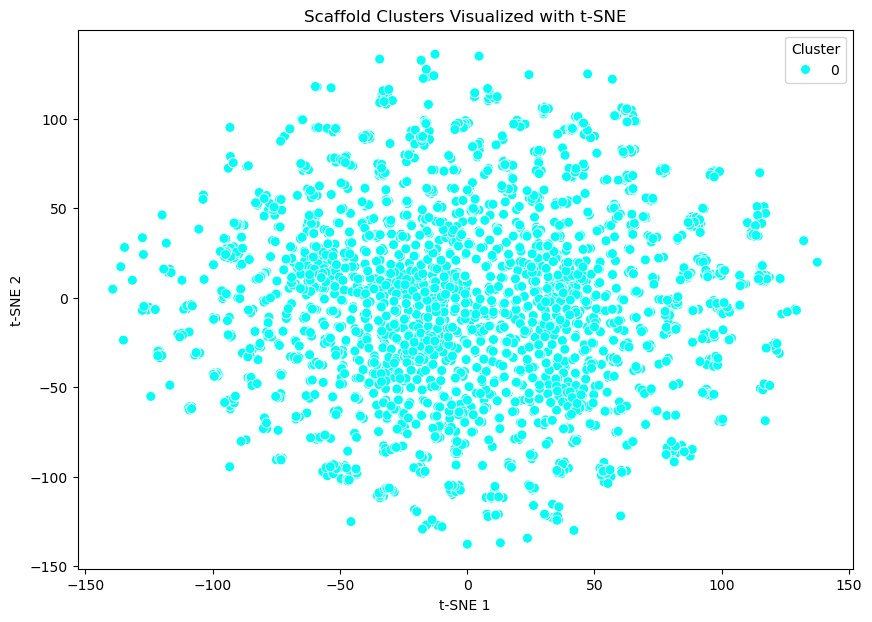

In [41]:
from rdkit.Chem import AllChem
from sklearn.cluster import AgglomerativeClustering
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Step 1: Generate fingerprints for scaffold molecules
scaffold_fps = [AllChem.GetMorganFingerprintAsBitVect(s, radius=2, nBits=1024) for s in scaffolds]

# Convert fingerprints to numpy arrays
def fp_to_array(fp):
    arr = np.zeros((1,), dtype=np.uint8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

scaffold_fp_arrays = np.array([fp_to_array(fp) for fp in scaffold_fps])

# Step 2: Cluster scaffolds
# Agglomerative clustering with distance threshold (e.g., 0.3 for similarity cutoff)
cluster_model = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=20.0,  # You may need to adjust this
    metric='euclidean',
    linkage='average'
)
cluster_labels = cluster_model.fit_predict(scaffold_fp_arrays)

# Step 3: Dimensionality reduction for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=10)
scaffold_tsne = tsne.fit_transform(scaffold_fp_arrays)

# Step 4: Plot clusters in 2D t-SNE space
plt.figure(figsize=(10,7))
palette = sns.color_palette("hsv", len(np.unique(cluster_labels)))
sns.scatterplot(x=scaffold_tsne[:,0], y=scaffold_tsne[:,1], hue=cluster_labels, palette=palette, legend='full', s=50)
plt.title("Scaffold Clusters Visualized with t-SNE")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title='Cluster')
plt.savefig('_images/cluster_scaffold_tsne.png')
plt.show()


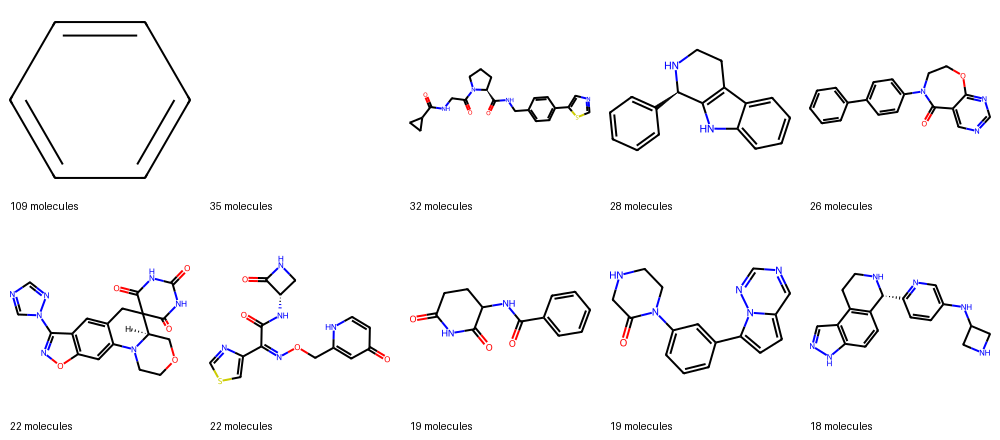

In [42]:
from rdkit import Chem
from rdkit.Chem import Draw
from PIL import Image, ImageDraw, ImageFont

top_n = 10
top_scaffolds = scaffold_counts.most_common(top_n)
scaffold_mols = [Chem.MolFromSmiles(smi) for smi, _ in top_scaffolds]
scaffold_labels = [f"{count} molecules" for _, count in top_scaffolds]

mol_size = (200, 200)
images = [Draw.MolToImage(mol, size=mol_size) for mol in scaffold_mols]

# Add labels to images
def add_label(img, label, size=(200, 220)):
    new_img = Image.new("RGB", size, "white")
    new_img.paste(img, (0, 0))
    draw = ImageDraw.Draw(new_img)
    draw.text((10, 200), label, fill="black") 
    return new_img

labeled_images = [add_label(img, label) for img, label in zip(images, scaffold_labels)]

cols = 5
rows = (len(labeled_images) + cols - 1) // cols
grid_width = mol_size[0] * cols
grid_height = 220 * rows 

grid_img = Image.new("RGB", (grid_width, grid_height), "white")

for idx, img in enumerate(labeled_images):
    x = (idx % cols) * mol_size[0]
    y = (idx // cols) * 220
    grid_img.paste(img, (x, y))

grid_img.save("_images/top_10_scaffolds.png")
display(grid_img)

Some groups but they're small. So we have a diverse dataset!

In [43]:
# Dump to file.

df_filtered.to_csv(DATA / f"{readout}_chembl.csv")